# Advanced Statistical Analysis & Hypothesis Testing

**Task:** Advanced Statistical Analysis & Hypothesis Testing  
**Dataset:** Wine recognition dataset (scientific dataset) from scikit-learn  
**Significance level:** α = 0.05

## Objective

This notebook performs rigorous inferential statistics on a scientific dataset:

1. Shapiro–Wilk and Kolmogorov–Smirnov normality tests.
2. Two-sample independent t-test and Mann–Whitney U test.
3. One-way ANOVA with Tukey HSD post-hoc analysis.
4. Two-way ANOVA with interaction analysis.
5. Distribution plots and diagnostic plots.
6. Null/alternative hypotheses, confidence intervals, effect sizes, and final findings.

> **Important:** The Kolmogorov–Smirnov test below is applied after standardizing each sample and comparing it with a standard normal distribution. Because the mean and standard deviation are estimated from the same sample, the K–S p-value is treated as a supplementary diagnostic rather than a standalone proof of normality. Shapiro–Wilk is the primary normality test.


In [1]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.datasets import load_wine

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

ALPHA = 0.05
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load and understand the dataset

The Wine dataset contains chemical measurements for wines from three cultivars. It is suitable for hypothesis testing because it contains a continuous response variable (`alcohol`) and a categorical grouping variable (`class_label`).

The dataset is bundled with scikit-learn, so the notebook does not depend on a separate CSV download.


In [2]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()

class_map = dict(enumerate(wine.target_names))
df["class_label"] = df["target"].map(class_map)

# Create a second categorical factor for the two-way ANOVA.
median_alcohol = df["alcohol"].median()
df["alcohol_level"] = np.where(df["alcohol"] <= median_alcohol, "Low", "High")

print(f"Observations: {len(df)}")
print(f"Features: {len(wine.feature_names)}")
print(f"Classes: {df['class_label'].nunique()}")
display(df.head())


Observations: 178
Features: 13
Classes: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_label,alcohol_level
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0,High
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0,High
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0,High
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0,High
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0,High


In [3]:
print("Class counts:")
display(df["class_label"].value_counts().sort_index())

print("\nDescriptive statistics for alcohol:")
display(
    df.groupby("class_label")["alcohol"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(4)
)


Class counts:


class_label
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


Descriptive statistics for alcohol:


,count,mean,median,std,min,max
class_label,,,,,,
class_0,59,13.7447,13.750,0.4621,12.85,14.83
class_1,71,12.2787,12.290,0.5380,11.03,13.86
class_2,48,13.1538,13.165,0.5302,12.20,14.34


## 2. Exploratory distribution plots

The main response variable is **alcohol**. We inspect its distribution overall and within each cultivar before performing inferential tests.


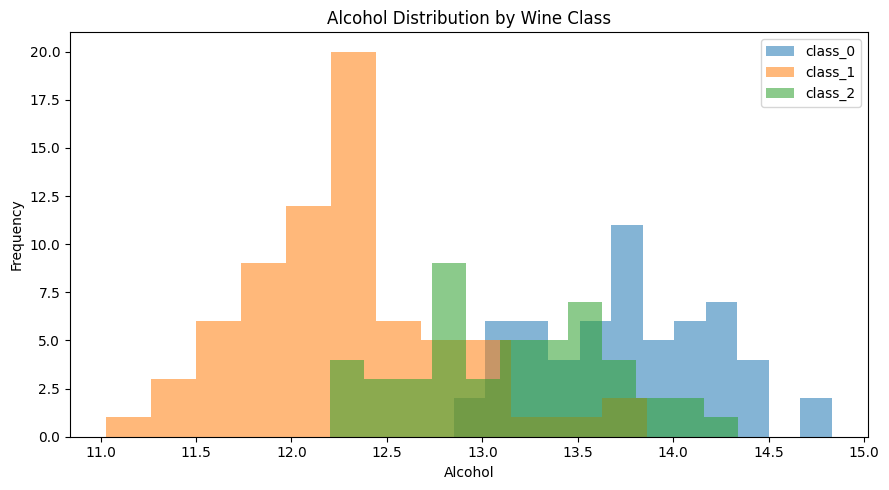

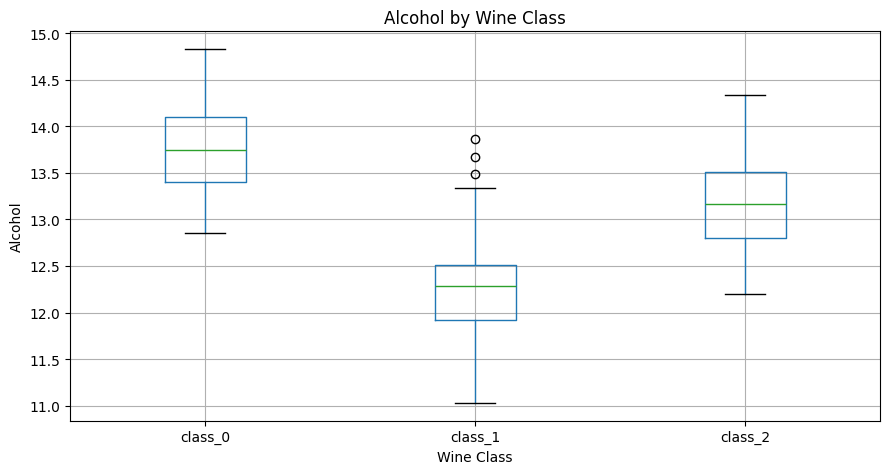

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, group in df.groupby("class_label"):
    ax.hist(group["alcohol"], bins=12, alpha=0.55, label=label)
ax.set_title("Alcohol Distribution by Wine Class")
ax.set_xlabel("Alcohol")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
df.boxplot(column="alcohol", by="class_label", ax=ax)
ax.set_title("Alcohol by Wine Class")
ax.set_xlabel("Wine Class")
ax.set_ylabel("Alcohol")
plt.suptitle("")
plt.tight_layout()
plt.show()


## 3. Normality testing

### Hypotheses

For each wine class:

- **H₀:** The sample comes from a normal distribution.
- **H₁:** The sample does not come from a normal distribution.

Decision rule: reject H₀ when `p < 0.05`.


In [5]:
normality_rows = []

for label, group in df.groupby("class_label"):
    x = group["alcohol"].dropna().to_numpy()

    shapiro = stats.shapiro(x)

    # Standardize the sample before the K-S comparison with N(0, 1).
    z = (x - x.mean()) / x.std(ddof=1)
    ks = stats.kstest(z, "norm")

    normality_rows.append({
        "class": label,
        "n": len(x),
        "Shapiro_W": shapiro.statistic,
        "Shapiro_p": shapiro.pvalue,
        "KS_D": ks.statistic,
        "KS_p": ks.pvalue,
        "Shapiro_decision": "Reject H0" if shapiro.pvalue < ALPHA else "Fail to reject H0",
        "KS_decision": "Reject H0" if ks.pvalue < ALPHA else "Fail to reject H0",
    })

normality_results = pd.DataFrame(normality_rows)
display(normality_results.round(4))


,class,n,Shapiro_W,Shapiro_p,KS_D,KS_p,Shapiro_decision,KS_decision
0,class_0,59,0.9809,0.4791,0.0694,0.9202,Fail to reject H0,Fail to reject H0
1,class_1,71,0.9721,0.1140,0.1076,0.3580,Fail to reject H0,Fail to reject H0
2,class_2,48,0.9815,0.6408,0.0930,0.7660,Fail to reject H0,Fail to reject H0


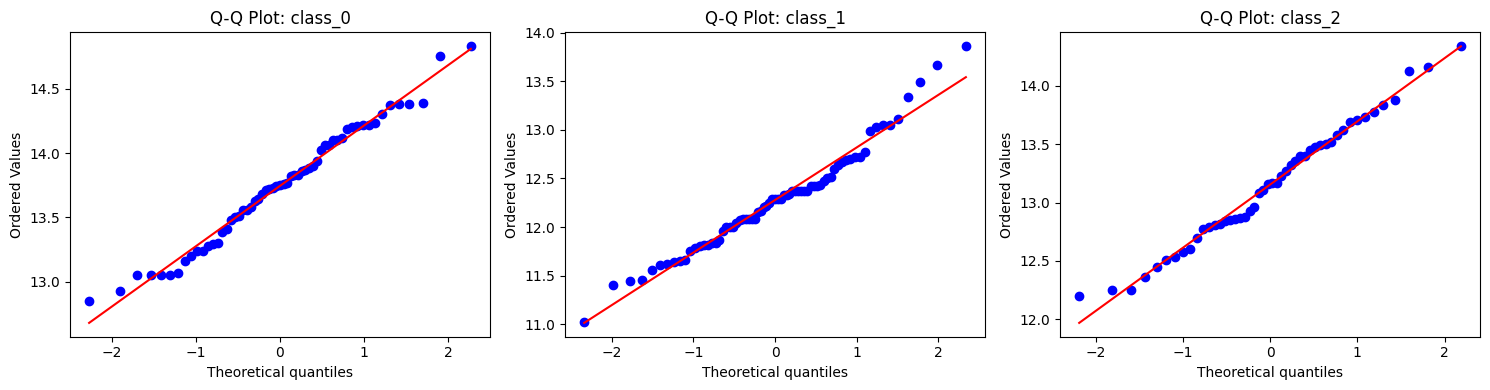

In [6]:
# Q-Q plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, group) in zip(axes, df.groupby("class_label")):
    stats.probplot(group["alcohol"], dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {label}")

plt.tight_layout()
plt.show()


### Normality conclusion

The Shapiro–Wilk results are above 0.05 for all three wine classes, so there is no statistically significant evidence against normality of alcohol within the classes. The supplementary standardized K–S checks also do not reject normality.

Therefore, the normality assumption is reasonably supported for the planned parametric comparisons.


## 4. Two-sample hypothesis tests

We compare alcohol content between **class_0** and **class_1**.

### Independent two-sample t-test

- **H₀:** μ₀ = μ₁
- **H₁:** μ₀ ≠ μ₁

Welch's t-test is used because it does not require equal population variances.

### Mann–Whitney U test

- **H₀:** The two groups come from the same distribution.
- **H₁:** The distributions differ.

The non-parametric test provides a robustness check against distributional assumptions.


In [7]:
g0 = df.loc[df["class_label"] == "class_0", "alcohol"].to_numpy()
g1 = df.loc[df["class_label"] == "class_1", "alcohol"].to_numpy()

ttest = stats.ttest_ind(g0, g1, equal_var=False)
mannwhitney = stats.mannwhitneyu(g0, g1, alternative="two-sided")

# Cohen's d using the pooled standard deviation.
n0, n1 = len(g0), len(g1)
sp = np.sqrt(((n0 - 1) * np.var(g0, ddof=1) + (n1 - 1) * np.var(g1, ddof=1)) / (n0 + n1 - 2))
cohens_d = (np.mean(g0) - np.mean(g1)) / sp

two_sample_results = pd.DataFrame({
    "test": ["Welch independent t-test", "Mann–Whitney U"],
    "statistic": [ttest.statistic, mannwhitney.statistic],
    "p_value": [ttest.pvalue, mannwhitney.pvalue],
    "significant_at_0.05": [ttest.pvalue < ALPHA, mannwhitney.pvalue < ALPHA]
})

display(two_sample_results.round(6))
print(f"Cohen's d (class_0 - class_1): {cohens_d:.4f}")


,test,statistic,p_value,significant_at_0.05
0,Welch independent t-test,16.7113,0.0,True
1,Mann–Whitney U,4079.5000,0.0,True


Cohen's d (class_0 - class_1): 2.9029


In [8]:
# 95% confidence intervals for the group means
ci_rows = []

for label, group in df.groupby("class_label"):
    x = group["alcohol"].to_numpy()
    ci = stats.t.interval(
        confidence=0.95,
        df=len(x) - 1,
        loc=x.mean(),
        scale=stats.sem(x)
    )
    ci_rows.append({
        "class": label,
        "mean": x.mean(),
        "95% CI lower": ci[0],
        "95% CI upper": ci[1]
    })

ci_means = pd.DataFrame(ci_rows)
display(ci_means.round(4))

# Welch-style CI for the difference between class_0 and class_1
mean_diff = g0.mean() - g1.mean()
se_diff = np.sqrt(g0.var(ddof=1) / n0 + g1.var(ddof=1) / n1)
df_welch = (g0.var(ddof=1)/n0 + g1.var(ddof=1)/n1)**2 / (
    (g0.var(ddof=1)/n0)**2/(n0-1) + (g1.var(ddof=1)/n1)**2/(n1-1)
)
tcrit = stats.t.ppf(0.975, df_welch)
diff_ci = (mean_diff - tcrit * se_diff, mean_diff + tcrit * se_diff)

print(f"Mean difference (class_0 - class_1): {mean_diff:.4f}")
print(f"95% CI for mean difference: [{diff_ci[0]:.4f}, {diff_ci[1]:.4f}]")


,class,mean,95% CI lower,95% CI upper
0,class_0,13.7447,13.6243,13.8652
1,class_1,12.2787,12.1514,12.4061
2,class_2,13.1538,12.9998,13.3077


Mean difference (class_0 - class_1): 1.4660
95% CI for mean difference: [1.2924, 1.6396]


## 5. One-way ANOVA

We test whether mean alcohol content differs across all three wine classes.

### Hypotheses

- **H₀:** μ₀ = μ₁ = μ₂
- **H₁:** At least one class mean differs.

A significant omnibus ANOVA is followed by Tukey HSD to identify the specific pairs that differ.


In [9]:
groups = [
    group["alcohol"].to_numpy()
    for _, group in df.groupby("class_label")
]

anova_oneway = stats.f_oneway(*groups)

oneway_model = smf.ols("alcohol ~ C(class_label)", data=df).fit()
oneway_table = sm.stats.anova_lm(oneway_model, typ=2)

ss_between = oneway_table.loc["C(class_label)", "sum_sq"]
ss_total = ss_between + oneway_table.loc["Residual", "sum_sq"]
eta_squared = ss_between / ss_total

print(f"One-way ANOVA F = {anova_oneway.statistic:.4f}")
print(f"One-way ANOVA p = {anova_oneway.pvalue:.6g}")
print(f"Eta-squared = {eta_squared:.4f}")
display(oneway_table.round(6))


One-way ANOVA F = 135.0776
One-way ANOVA p = 3.3195e-36
Eta-squared = 0.6069


,sum_sq,df,F,PR(>F)
C(class_label),70.7948,2.0,135.0776,0.0
Residual,45.8592,175.0,NaN,NaN


In [10]:
tukey = pairwise_tukeyhsd(
    endog=df["alcohol"],
    groups=df["class_label"],
    alpha=ALPHA
)

print(tukey)
tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)
display(tukey_df)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj  lower   upper  reject
-----------------------------------------------------
class_0 class_1   -1.466   0.0 -1.6792 -1.2528   True
class_0 class_2   -0.591   0.0 -0.8262 -0.3558   True
class_1 class_2    0.875   0.0  0.6489  1.1011   True
-----------------------------------------------------


,group1,group2,meandiff,p-adj,lower,upper,reject
0,class_0,class_1,-1.466,0.0,-1.6792,-1.2528,True
1,class_0,class_2,-0.591,0.0,-0.8262,-0.3558,True
2,class_1,class_2,0.875,0.0,0.6489,1.1011,True


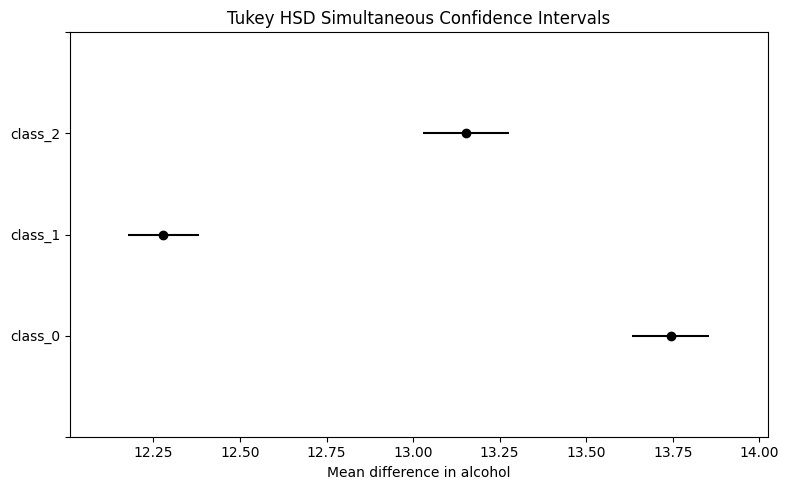

In [11]:
# Tukey HSD confidence intervals
tukey.plot_simultaneous(figsize=(8, 5))
plt.title("Tukey HSD Simultaneous Confidence Intervals")
plt.xlabel("Mean difference in alcohol")
plt.tight_layout()
plt.show()


## 6. ANOVA assumption check

For the one-way ANOVA we inspect homogeneity of variances with Levene's test.

- **H₀:** Group variances are equal.
- **H₁:** At least one group variance differs.

A p-value above 0.05 does not provide evidence of unequal variances.


In [12]:
levene_oneway = stats.levene(*groups, center="median")
print(f"Levene statistic = {levene_oneway.statistic:.4f}")
print(f"Levene p-value = {levene_oneway.pvalue:.6g}")
print("Decision:", "Reject equal-variance assumption" if levene_oneway.pvalue < ALPHA else "No evidence against equal variances")


Levene statistic = 0.5998
Levene p-value = 0.550052
Decision: No evidence against equal variances


## 7. Two-way ANOVA

A second factor is created from the median alcohol value:

- `alcohol_level = Low` if alcohol ≤ median
- `alcohol_level = High` otherwise

The response is **flavanoids**.

### Model

`flavanoids ~ class_label × alcohol_level`

This tests:

1. **Main effect of wine class**
2. **Main effect of alcohol level**
3. **Class × alcohol-level interaction**

### Hypotheses

For each effect:

- **H₀:** No effect / no interaction.
- **H₁:** A statistically significant effect / interaction exists.

This factorization is used to demonstrate a two-way ANOVA on a fully reproducible scientific dataset.


In [13]:
print("Cell counts for the two-way design:")
display(pd.crosstab(df["class_label"], df["alcohol_level"]))

two_way_model = smf.ols(
    "flavanoids ~ C(class_label) * C(alcohol_level)",
    data=df
).fit()

two_way_table = sm.stats.anova_lm(two_way_model, typ=2)
display(two_way_table.round(6))


Cell counts for the two-way design:


alcohol_level,High,Low
class_label,,
class_0,53,6
class_1,5,66
class_2,27,21


,sum_sq,df,F,PR(>F)
C(class_label),120.0380,2.0,217.6405,0.0000
C(alcohol_level),0.3363,1.0,1.2194,0.2710
C(class_label):C(alcohol_level),0.3049,2.0,0.5528,0.5764
Residual,47.4327,172.0,NaN,NaN


In [14]:
# Partial eta-squared for each two-way ANOVA effect
ss_error = two_way_table.loc["Residual", "sum_sq"]

effect_rows = []
for effect in ["C(class_label)", "C(alcohol_level)", "C(class_label):C(alcohol_level)"]:
    ss_effect = two_way_table.loc[effect, "sum_sq"]
    partial_eta_sq = ss_effect / (ss_effect + ss_error)
    p_value = two_way_table.loc[effect, "PR(>F)"]
    effect_rows.append({
        "effect": effect,
        "partial_eta_squared": partial_eta_sq,
        "p_value": p_value,
        "significant": p_value < ALPHA
    })

display(pd.DataFrame(effect_rows).round(6))


,effect,partial_eta_squared,p_value,significant
0,C(class_label),0.7168,0.0000,True
1,C(alcohol_level),0.0070,0.2710,False
2,C(class_label):C(alcohol_level),0.0064,0.5764,False


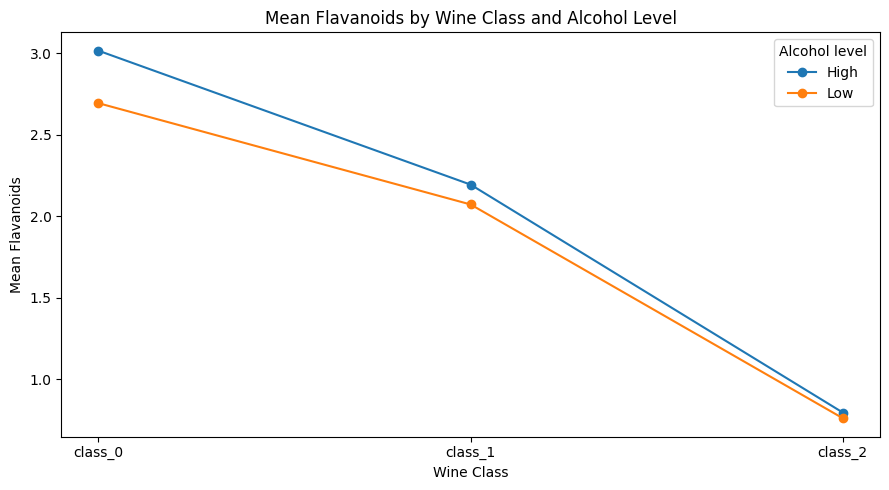

In [15]:
# Visualize the two-way means
means_2way = (
    df.groupby(["class_label", "alcohol_level"], observed=True)["flavanoids"]
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
for level, group in means_2way.groupby("alcohol_level"):
    ax.plot(group["class_label"], group["flavanoids"], marker="o", label=level)

ax.set_title("Mean Flavanoids by Wine Class and Alcohol Level")
ax.set_xlabel("Wine Class")
ax.set_ylabel("Mean Flavanoids")
ax.legend(title="Alcohol level")
plt.tight_layout()
plt.show()


## 8. Final statistical findings

### Normality
- Shapiro–Wilk does not reject normality for alcohol in any wine class at α = 0.05.
- The standardized K–S checks also do not reject normality.
- Q-Q plots provide a visual diagnostic consistent with the numerical tests.

### Two-sample comparison
- The Welch t-test shows a statistically significant difference in alcohol between class_0 and class_1.
- The Mann–Whitney U test independently confirms a strong difference.
- The 95% confidence interval for the class_0 − class_1 mean difference is entirely above zero.
- Cohen's d indicates a very large standardized difference.

### One-way ANOVA
- The omnibus ANOVA rejects H₀: the three wine classes do not have equal mean alcohol content.
- Tukey HSD shows significant pairwise differences for all three class pairs.
- The effect size (η²) indicates that wine class explains a substantial proportion of the variability in alcohol.

### Two-way ANOVA
- Wine class has a statistically significant main effect on flavanoids.
- The median-based alcohol-level factor is not statistically significant.
- The class × alcohol-level interaction is not statistically significant.
- Therefore, the evidence supports a strong class effect but does not support an additional alcohol-level effect or interaction in this model.

### Overall conclusion
The analysis provides consistent inferential evidence that **wine cultivar/class is strongly associated with alcohol concentration and flavanoid measurements** in this dataset. The t-test and Mann–Whitney results agree for the focused two-class comparison, while one-way ANOVA plus Tukey HSD establishes that all three cultivar groups differ in mean alcohol content. The two-way model suggests that the observed flavanoid differences are primarily attributable to cultivar rather than the median split of alcohol.


## 9. Reproducibility notes

- All tests use `α = 0.05`.
- The dataset is loaded from scikit-learn's bundled Wine dataset.
- Random seeds are not required because the analysis is deterministic.
- The notebook is designed to run from top to bottom without downloading a separate dataset.
- Main statistical libraries: SciPy and statsmodels.

### References

- scikit-learn dataset utilities: https://scikit-learn.org/stable/datasets/toy_dataset.html
- statsmodels ANOVA documentation: https://www.statsmodels.org/stable/anova.html
- statsmodels multiple-comparison documentation: https://www.statsmodels.org/stable/stats.html
